# ChemKey — one structure, every name

I start with a common name, look at what the index finds, and then check the actual evidence. The workflow follows the app: **molecule → name comparison → evidence → conversation → plots → retrieval insights → original papers**.

This is a saved, executed demo: read the outputs below without running any cells. To interact or change inputs, use the **Python (chemkey-rag)** kernel and run in order. The answer-model cells are enabled and call OpenRouter when rerun; the other steps use local files. No Streamlit server is needed.

In [1]:
from pathlib import Path
import ast
import html
import json
import os
import re
import subprocess

from IPython.display import HTML, Markdown, SVG, display, clear_output
from dotenv import load_dotenv
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
import chemkey as ck
import evidence_plots as plots

ROOT = Path.cwd()
index_ready = (ROOT / "data/index.json").is_file()
if not index_ready:
    print("No index found. Add PDFs to papers/ and run python build_index.py.")
load_dotenv(ROOT / ".env")  # Load credentials without printing them.
index = ck.load_index(str(ROOT / "data/index.json")) if index_ready else {"chunks": [], "compounds": {}}
chunks = index["chunks"]
documents = sorted({c["source_doc"] for c in chunks})

# Read the app's example and preset constants without importing or running its UI.
ui_tree = ast.parse((ROOT / "streamlit_app.py").read_text())
def app_constant(name):
    node = next(node for node in ui_tree.body if isinstance(node, ast.Assign)
                and any(isinstance(t, ast.Name) and t.id == name for t in node.targets))
    return ast.literal_eval(node.value)
EXAMPLES = app_constant("EXAMPLES")
PRESETS = app_constant("PRESET_QUESTIONS")
print(f"{len(documents)} papers · {len(chunks)} passages · {len(index['compounds'])} indexed names")

def local_link(path):
    relative = path.relative_to(ROOT).as_posix()
    display(HTML(f'<a href="{html.escape(relative, quote=True)}" target="_blank">{html.escape(relative)}</a>'))

3 papers · 246 passages · 80 indexed names


## Choose a molecule

The default is **paracetamol**, just as in the app. Change `example` to another entry below, or enter a different `name_query`. For a direct structure query, set `search_by = "SMILES"` and supply `smiles_input`.

An unresolved name stops here; it never silently falls back to the example structure.

Examples: Paracetamol, Phenacetin, Acetanilide, Caffeine, Benzocaine, Carbamazepine (not in corpus)


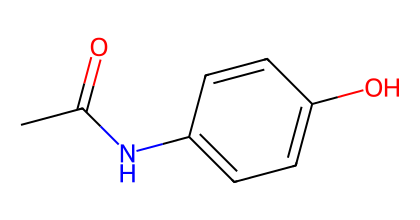

Connectivity: RZVAJINKPMORJF
Full InChIKey: RZVAJINKPMORJF-UHFFFAOYSA-N


In [2]:
if not index_ready:
    print("Skipped: build the index, then rerun this notebook.")
else:
    print("Examples:", ", ".join(EXAMPLES))
    
    example = "Paracetamol"
    search_by = "Chemical name"  # or "SMILES"
    name_query = EXAMPLES[example][1]
    smiles_input = EXAMPLES[example][0]
    allow_pubchem = False
    source_limit = 6
    
    resolver = ck.NameResolver(online=allow_pubchem)
    query_smiles = resolver.resolve(name_query) if search_by == "Chemical name" else smiles_input
    if not query_smiles:
        raise ValueError("Name not resolved. Try another name, enable PubChem, or enter SMILES.")
    full_key, block = ck.to_inchikey(query_smiles)
    if not block:
        raise ValueError("Invalid SMILES; correct the input before continuing.")
    subject_label = name_query if search_by == "Chemical name" else "Selected structure"
    names = sorted(name for name, record in index["compounds"].items() if record["block"] == block)
    subject = {"label": subject_label, "block": block, "names": names}
    
    mol = Chem.MolFromSmiles(query_smiles)
    drawer = rdMolDraw2D.MolDraw2DSVG(420, 220)
    rdMolDraw2D.PrepareAndDrawMolecule(drawer, mol)
    drawer.FinishDrawing()
    display(SVG(drawer.GetDrawingText()))
    print("Connectivity:", block)
    print("Full InChIKey:", full_key)


## Different names. Same molecule.

Each row is an **exact-name** search, including any CAS identifier recorded in the index. Structure retrieval joins those names through one connectivity key. The counts below use the same word-boundary matching as the UI.

These sets overlap. “Beyond this name” means passages found only by structure, not structure total minus text total.

After fixing hyphenated-name extraction and rebuilding, paracetamol has 133 structure passages and 133 across all indexed spellings. The earlier 132/133 result missed a reference containing `Paracetamol-Oxalic`.

In [3]:
if not index_ready:
    print("Skipped: build the index, then rerun this notebook.")
else:
    def show_table(headers, rows):
        heading = "".join(f"<th style='text-align:left;padding:8px'>{html.escape(str(h))}</th>" for h in headers)
        body = "".join("<tr>" + "".join(f"<td style='padding:8px;border-top:1px solid #aaa4'>{html.escape(str(v))}</td>" for v in row) + "</tr>" for row in rows)
        display(HTML(f"<table><thead><tr>{heading}</tr></thead><tbody>{body}</tbody></table>"))
    
    def text_ids(name):
        pattern = re.compile(r"\b" + re.escape(name) + r"\b", re.I)
        return {i for i, c in enumerate(chunks) if pattern.search(c["text"])} if name else set()
    
    def structure_ids(key):
        return {i for i, c in enumerate(chunks) if key in c["blocks"]}
    
    structural = structure_ids(block)
    literal = text_ids(name_query) if search_by == "Chemical name" else set()
    comparison_names = list(names)
    if search_by == "Chemical name" and not any(n.casefold() == name_query.casefold() for n in names):
        comparison_names.append(name_query)
    show_table(["Name / identifier", "Exact-name passages", "Query"], [
        (("CAS " if re.fullmatch(r"\d{2,7}-\d{2}-\d", name) else "") + name,
         len(text_ids(name)), "Your query" if search_by == "Chemical name" and name.casefold() == name_query.casefold() else "")
        for name in comparison_names
    ])
    mentions = ck.documents_for_structure(query_smiles, index)
    print(f"Structure: {len(structural)} passages across {len(mentions)} papers")
    if search_by == "Chemical name":
        print(f"Beyond this exact name: +{len(structural - literal)} passages")
        print(f"Shared: {len(structural & literal)} · text only: {len(literal - structural)}")


Name / identifier,Exact-name passages,Query
CAS 103-90-2,2,
acetaminophen,62,
n-(4-hydroxyphenyl)acetamide,1,
paracetamol,83,Your query


Structure: 133 passages across 3 papers
Beyond this exact name: +50 passages
Shared: 83 · text only: 0


## Evidence explorer

Here I can narrow the topic and select papers without calling a model. As in the app, these filters apply to this evidence view; chat searches the full library for the selected structure. Ranked retrieval excludes detected bibliographies, whereas the coverage counts above include them.

In [4]:
if not index_ready:
    print("Skipped: build the index, then rerun this notebook.")
else:
    topic = "solubility"
    selected_papers = []  # Empty means all papers; otherwise use filenames from `documents`.
    scoped_index = {**index, "chunks": [c for c in chunks if not selected_papers or c["source_doc"] in selected_papers]}
    evidence, _ = ck.structure_search(query_smiles, scoped_index, topic, top_k=source_limit)
    
    def show_sources(sources):
        if not sources:
            print("No matching passages.")
        for number, source in enumerate(sources, 1):
            title = f"Source {number} · {source['source_doc']} · page {source['page_number']} · {source.get('route', 'indexed')}"
            preview = source["text"][:240] + ("…" if len(source["text"]) > 240 else "")
            note = "Includes surrounding page text to preserve tables." if source.get("context_scope") else "Matched passage"
            display(HTML(f"<div style='margin:14px 0'><b>{html.escape(title)}</b><p>{html.escape(preview)}</p><details><summary>Read full passage</summary><p>{note}</p><p style='white-space:pre-wrap'>{html.escape(source['text'])}</p></details></div>"))
    
    show_sources(evidence)


In [5]:
if not index_ready:
    print("Skipped: build the index, then rerun this notebook.")
else:
    # Optional export: turn this on when you want a file to keep.
    export_evidence = False
    output_dir = ROOT / "notebook_outputs"
    if export_evidence:
        output_dir.mkdir(exist_ok=True)
        destination = output_dir / "evidence.json"
        destination.write_text(json.dumps({"query": subject_label, "smiles": query_smiles,
                                          "block": block, "sources": evidence}, indent=2))
        local_link(destination)


## Ask the library

This is the same chat path as the app: `conversation_search` selects structure-matched anchors, then includes their surrounding page text. That matters for Table 1—the caption and numerical rows occupy different chunks.

A page can contain several compounds. The answer model receives the selected molecule and must read the table abbreviations before assigning values. Citations restart at Source 1 on each turn.

The first cell only retrieves evidence. The saved run includes a generated answer (`enable_model = True`). Set it to `False` before rerunning if you only want offline retrieval. That sends the question, recent conversation and retrieved text to OpenRouter using the key from `.env`.

In [6]:
if not index_ready:
    print("Skipped: build the index, then rerun this notebook.")
else:
    enable_model = True
    question = PRESETS[1][1]  # Solubility table; PRESETS[0] is the coformer question.
    print(question)
    
    # Re-running this cell preserves the conversation for the same structure.
    if globals().get("conversation_block") != block:
        conversation_block = block
        conversation = []
    chat_sources, _ = ck.conversation_search(question, query_smiles, index,
                                             history=conversation, top_k=source_limit)
    show_table(["Source", "Paper", "Page", "Context chunks"], [
        (i, s["source_doc"], s["page_number"], s.get("context_chunks", 1))
        for i, s in enumerate(chat_sources, 1)
    ])
    assert all(block in s["blocks"] for s in chat_sources)
    print("All retrieved anchors match the selected connectivity key.")


What are the measured solubility values in DMSO + water mixtures at different temperatures?


Source,Paper,Page,Context chunks
1,B_acetaminophen_solubility.pdf,10,4
2,B_acetaminophen_solubility.pdf,9,4
3,B_acetaminophen_solubility.pdf,4,5
4,B_acetaminophen_solubility.pdf,13,3
5,B_acetaminophen_solubility.pdf,15,5


All retrieved anchors match the selected connectivity key.


In [7]:
if not index_ready:
    print("Skipped: build the index, then rerun this notebook.")
else:
    def ask(question):
        """Continue this molecule's conversation; a failed request leaves history intact."""
        global conversation, conversation_block
        if conversation_block != block:
            conversation, conversation_block = [], block
        sources, _ = ck.conversation_search(question, query_smiles, index,
                                            history=conversation, top_k=source_limit)
        if not enable_model:
            print("Model calls are off. Set enable_model = True to generate an answer.")
            return None
        key = os.getenv("OPENROUTER_API_KEY", "")
        if not key:
            print("Add OPENROUTER_API_KEY to .env, then rerun the setup cell.")
            return None
        try:
            raw = ck.ask_openrouter(question, sources, key, history=conversation, subject=subject)
        except ck.requests.RequestException as error:
            print(f"The answer service could not complete the request ({type(error).__name__}). You can retry.")
            return None
        answer, followups = ck.split_answer_followups(raw)
        message = {"role": "assistant", "content": answer, "sources": sources,
                   "followups": followups, "plots": plots.solubility_tables(sources, block)}
        conversation.extend([{"role": "user", "content": question}, message])
        display(Markdown(answer))
        if followups:
            show_table(["Next question", "Suggestion"], enumerate(followups, 1))
        return message
    
    latest_answer = ask(question)


The table below reports the solubility of acetaminophen (paracetamol) in DMSO + water binary mixtures, measured in this work. Solubility is given as mole fraction × 10² (xA × 10²) at four temperatures and six solvent compositions (x₂* = mole fraction of DMSO in the organic‑aqueous mixture). Values are from Table 1 of the paper [Source 1].

| x₂* (DMSO mole fraction) | Temperature (°C) | Solubility (xA × 10²) | Type | Source |
|---|---|---|---|---|
| 0.0 | 25 | 0.20 ± 0.01 | measured in this work | [Source 1] |
| 0.0 | 30 | 0.24 ± 0.01 | measured in this work | [Source 1] |
| 0.0 | 35 | 0.28 ± 0.01 | measured in this work | [Source 1] |
| 0.0 | 40 | 0.32 ± 0.01 | measured in this work | [Source 1] |
| 0.2 | 25 | 5.17 ± 0.05 | measured in this work | [Source 1] |
| 0.2 | 30 | 7.22 ± 0.38 | measured in this work | [Source 1] |
| 0.2 | 35 | 9.98 ± 0.17 | measured in this work | [Source 1] |
| 0.2 | 40 | 13.66 ± 0.51 | measured in this work | [Source 1] |
| 0.4 | 25 | 13.65 ± 0.37 | measured in this work | [Source 1] |
| 0.4 | 30 | 18.37 ± 0.21 | measured in this work | [Source 1] |
| 0.4 | 35 | 23.79 ± 0.92 | measured in this work | [Source 1] |
| 0.4 | 40 | 31.47 ± 1.15 | measured in this work | [Source 1] |
| 0.6 | 25 | 26.47 ± 0.89 | measured in this work | [Source 1] |
| 0.6 | 30 | 31.69 ± 0.99 | measured in this work | [Source 1] |
| 0.6 | 35 | 37.95 ± 0.67 | measured in this work | [Source 1] |
| 0.6 | 40 | 45.23 ± 0.79 | measured in this work | [Source 1] |
| 0.8 | 25 | 31.61 ± 0.95 | measured in this work | [Source 1] |
| 0.8 | 30 | 37.03 ± 0.96 | measured in this work | [Source 1] |
| 0.8 | 35 | 43.38 ± 0.54 | measured in this work | [Source 1] |
| 0.8 | 40 | 51.08 ± 0.78 | measured in this work | [Source 1] |
| 1.0 | 25 | 30.30 ± 0.55 | measured in this work | [Source 1] |
| 1.0 | 30 | 35.76 ± 0.71 | measured in this work | [Source 1] |
| 1.0 | 35 | 42.22 ± 1.02 | measured in this work | [Source 1] |
| 1.0 | 40 | 48.92 ± 0.62 | measured in this work | [Source 1] |

Next question,Suggestion
1,What are the measured solubility values in DMF + water mixtures at different temperatures?
2,What are the measured solubility values in 4-formylmorpholine + water mixtures at different temperatures?
3,Which solvent mixture gave the highest solubility for paracetamol at 25 °C?


### Continue the discussion

A follow-up such as “How do those layers connect?” needs earlier turns. Use `ask(...)` again; don't start a fresh retrieval without history. The controls below offer the same presets, suggested questions and Clear action as the app. They are optional—plain cells work too.

In [8]:
if not index_ready:
    print("Skipped: build the index, then rerun this notebook.")
else:
    # To continue in a plain cell:
    # latest_answer = ask("How do hydrogen bonds hold those layers together?")
    # latest_answer = ask(latest_answer["followups"][0])
    
    try:
        import ipywidgets as widgets
        entry = widgets.Textarea(placeholder="Ask about this molecule…", layout=widgets.Layout(width="100%"))
        send = widgets.Button(description="Ask", button_style="primary")
        reset = widgets.Button(description="Clear")
        suggestions = widgets.VBox()
        transcript = widgets.Output()
    
        def refresh_suggestions():
            questions = conversation[-1].get("followups", []) if conversation else []
            buttons = []
            for suggestion in questions:
                button = widgets.Button(description=suggestion, tooltip=suggestion,
                                        layout=widgets.Layout(width="100%"))
                button.on_click(lambda _, q=suggestion: submit(q))
                buttons.append(button)
            suggestions.children = tuple(buttons)
    
        def submit(text):
            if not text.strip():
                return
            send.disabled = True
            try:
                with transcript:
                    display(Markdown("**You:** " + text))
                    ask(text)
                entry.value = ""
                refresh_suggestions()
            finally:
                send.disabled = False
    
        def clear_chat(_):
            conversation.clear()
            transcript.clear_output()
            refresh_suggestions()
    
        send.on_click(lambda _: submit(entry.value))
        reset.on_click(clear_chat)
        preset_buttons = []
        for label, prompt, _ in PRESETS:
            button = widgets.Button(description=label)
            button.on_click(lambda _, q=prompt: submit(q))
            preset_buttons.append(button)
        refresh_suggestions()
        display(widgets.VBox([widgets.HBox(preset_buttons), entry,
                              widgets.HBox([send, reset]), transcript, suggestions]))
    except ImportError:
        print("ipywidgets is optional. Use ask(question) in a cell instead.")


## Plot source data

The chart uses the same verified Table 1 parser and renderer as the UI. It reads retrieved text, **not the generated answer**. Values are mole fractions × 100; bars show the paper's reported ± uncertainty. Lines connect measured points and are not predictions.

Currently supported: paracetamol in DMSO/DMF/4FM + water, and phenacetin in 4FM + water. Qualitative coformer findings stay in the cited answer. An incomplete or unsupported table produces no plot.

System,Measurements,Source,Page
Paracetamol · DMSO + water,24,1,10
Paracetamol · DMF + water,20,1,10
Paracetamol · 4FM + water,20,1,10


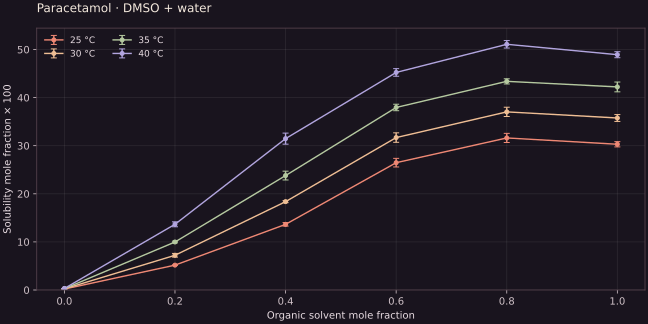

Measured · Table 1 · B_acetaminophen_solubility.pdf · page 10 · Source 1


In [9]:
if not index_ready:
    print("Skipped: build the index, then rerun this notebook.")
else:
    plot_sources = latest_answer["sources"] if latest_answer else chat_sources
    plot_tables = plots.solubility_tables(plot_sources, block)
    show_table(["System", "Measurements", "Source", "Page"], [
        (t["title"], len(t["rows"]), t["source"], t["page"]) for t in plot_tables
    ])
    
    solvent = "DMSO"
    horizontal_axis = "Composition"  # or "Temperature"
    plot_table = next((t for t in plot_tables if t["solvent"] == solvent), None)
    plot_svg = None
    if plot_table:
        try:
            plot_svg = plots.render_svg(plot_table, horizontal_axis)
            display(SVG(plot_svg))
            print(f"Measured · Table 1 · {plot_table['source_doc']} · page {plot_table['page']} · Source {plot_table['source']}")
        except (subprocess.SubprocessError, OSError):
            print("Plot rendering failed; the table and sources are still available.")
    else:
        print("No verified table for this molecule and solvent in the retrieved evidence.")


In [10]:
if not index_ready:
    print("Skipped: build the index, then rerun this notebook.")
else:
    # Export only when requested; rerunning the notebook does not overwrite files by default.
    export_plot = False
    if export_plot and plot_table:
        output_dir.mkdir(exist_ok=True)
        csv_path = output_dir / f"{block}-{solvent}-solubility.csv"
        csv_path.write_text(plots.table_csv(plot_table))
        local_link(csv_path)
        if plot_svg:
            svg_path = output_dir / f"{block}-{solvent}-{horizontal_axis}.svg"
            svg_path.write_text(plot_svg)
            local_link(svg_path)


## Retrieval insights: the fair comparison

One name is a useful baseline, but it is not the strongest text baseline. Here I combine every indexed spelling, just as the app does. Structure coverage can be smaller than this union; resolution is not perfect.

For the common-name query, the top text hits may already match the selected structure. In that case, structure filtering leaves the same top passages; the coverage table above measures the broader name-independent reach.

In [11]:
if not index_ready:
    print("Skipped: build the index, then rerun this notebook.")
else:
    spelling_sets = [text_ids(name) for name in comparison_names]
    all_spellings = set().union(*spelling_sets) if spelling_sets else set()
    show_table(["Comparison", "Passages"], [
        ("Structure", len(structural)),
        ("All indexed spellings + current name", len(all_spellings)),
        ("Only structure finds", len(structural - all_spellings)),
        ("Only spellings find", len(all_spellings - structural)),
    ])
    
    text_ranked = ck.bm25_search(name_query, chunks, top_k=source_limit)
    structure_ranked, _ = ck.structure_search(query_smiles, index, name_query, top_k=source_limit)
    show_table(["Route", "Paper", "Page", "BM25 score"], [
        (label, s["source_doc"], s["page_number"], s["score"])
        for label, results in [("Text", text_ranked), ("Structure", structure_ranked)] for s in results
    ])
    print("BM25 matches tokens, so its ranked results are not the exact-name counts above.")


Comparison,Passages
Structure,133
All indexed spellings + current name,133
Only structure finds,0
Only spellings find,0


Route,Paper,Page,BM25 score
Text,A_paracetamol_cocrystals.pdf,3,2.455
Text,A_paracetamol_cocrystals.pdf,6,2.337
Text,A_paracetamol_cocrystals.pdf,3,2.25
Text,A_paracetamol_cocrystals.pdf,9,2.228
Text,A_paracetamol_cocrystals.pdf,5,2.224
Text,A_paracetamol_cocrystals.pdf,6,2.215
Structure,A_paracetamol_cocrystals.pdf,3,1.187
Structure,A_paracetamol_cocrystals.pdf,6,1.133
Structure,A_paracetamol_cocrystals.pdf,3,1.092
Structure,A_paracetamol_cocrystals.pdf,9,1.082


BM25 matches tokens, so its ranked results are not the exact-name counts above.


### Why caffeine says “+3”

This example is easy to misread: the rebuilt index has 7 exact-name passages and 10 structure passages, with all 7 shared. The three additional structure hits contain the PDF-split spelling `ca ffeine`. The hyphen repair also recovers the formerly text-only caffeine passage; none are text-only in the rebuilt index. The cell below measures this instead of subtracting the totals.

In [12]:
if not index_ready:
    print("Skipped: build the index, then rerun this notebook.")
else:
    caffeine_smiles = resolver.resolve("caffeine")
    _, caffeine_block = ck.to_inchikey(caffeine_smiles)
    caffeine_text = text_ids("caffeine")
    caffeine_structure = structure_ids(caffeine_block)
    show_table(["Set", "Passages"], [
        ("Exact caffeine", len(caffeine_text)), ("Structure", len(caffeine_structure)),
        ("Shared", len(caffeine_text & caffeine_structure)),
        ("Structure only", len(caffeine_structure - caffeine_text)),
        ("Text only", len(caffeine_text - caffeine_structure)),
    ])
    for i in sorted(caffeine_structure - caffeine_text):
        c = chunks[i]
        match = re.search(r"c\s*a\s*f\s*f\s*e\s*i\s*n\s*e", c["text"], re.I)
        excerpt = c["text"][max(0, match.start()-45):match.end()+45] if match else c["text"][:150]
        print(f"{c['source_doc']} · page {c['page_number']}: {excerpt}")


Set,Passages
Exact caffeine,7
Structure,10
Shared,7
Structure only,3
Text only,0


C_excess_solubility_simulation.pdf · page 1: , acetaminophen, phenacetin, benzocaine, and ca ffeine in binary water /ethanol solvents. The simul
C_excess_solubility_simulation.pdf · page 7:  solvent, where component 1 is benzocaine or ca ffeine, as indicated. Simulation results are shown 
C_excess_solubility_simulation.pdf · page 8: , acetaminophen, phenacetin, benzocaine, and ca ffeine in binary water /ethanol mixtures. The solut


## Source library

The PDFs are the final check. In particular, paper B mixes the authors' measurements, values collected from literature, and predictions. Those are different kinds of evidence, even when they appear on the same page.

In [4]:
if not index_ready:
    print("Skipped: build the index, then rerun this notebook.")
else:
    show_table(["Paper", "Indexed passages", "Pages with indexed text"], [
        (doc, sum(c["source_doc"] == doc for c in chunks),
         len({c["page_number"] for c in chunks if c["source_doc"] == doc})) for doc in documents
    ])
    for doc in documents:
        path = ROOT / "papers" / Path(doc).name
        if path.exists():
            local_link(path)


Paper,Indexed passages,Pages with indexed text
A_paracetamol_cocrystals.pdf,89,17
B_acetaminophen_solubility.pdf,89,19
C_excess_solubility_simulation.pdf,68,10


## A few checks before trusting the result

These checks catch the problems that mattered during development: losing the selected structure, retrieving a table caption without its numbers, and confusing additional coverage with a net count difference. They use the local files and do not call the model.

In [14]:
if not index_ready:
    print("Skipped: build the index, then rerun this notebook.")
else:
    from pypdf import PdfReader
    
    paracetamol = EXAMPLES["Paracetamol"][0]
    prior_turns = [
        {"role": "user", "content": PRESETS[0][1]},
        {"role": "assistant", "content": "Illustrative prior topic: paracetamol cocrystals and hydrogen bonding."},
    ]
    solubility_sources, paracetamol_block = ck.conversation_search(
        PRESETS[1][1], paracetamol, index, history=prior_turns, top_k=6)
    assert all(paracetamol_block in s["blocks"] for s in solubility_sources)
    tables = plots.solubility_tables(solubility_sources, paracetamol_block)
    dmso = next(t for t in tables if t["solvent"] == "DMSO")
    pdf_page = PdfReader(ROOT / "papers/B_acetaminophen_solubility.pdf").pages[9].extract_text()
    assert len(dmso["rows"]) == 24
    assert dmso["rows"][0]["solubility_x100"] == 0.20
    assert dmso["rows"][-1]["solubility_x100"] == 48.92
    assert all(value in pdf_page for value in ["0.20", "5.17", "13.66", "51.08", "48.92"])
    assert len(caffeine_structure - caffeine_text) == 3
    absent, _ = ck.conversation_search("solubility", EXAMPLES["Carbamazepine (not in corpus)"][0], index)
    assert not absent
    print("Passed: structure scoping, Table 1 values against the PDF, caffeine overlap, absent-molecule control.")


Passed: structure scoping, Table 1 values against the PDF, caffeine overlap, absent-molecule control.


The main limitation is still the corpus: the index reads text, not molecules drawn only in figures. Connectivity matching also groups stereoisomers. A cited answer is inspectable, not automatically correct; keep the source page open when checking a measurement.